In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from scipy.stats import norm, binom
import os

pd.set_option('display.width', 170)
OUT_DIR = 'outputs'; FIG_DIR = 'outputs/figures'; os.makedirs(FIG_DIR, exist_ok=True)
RAW_PATH = 'Enabel_DATA_LABELS_2026-06-20_1834.csv'
rng = np.random.default_rng(0)

d = pd.read_parquet(f'{OUT_DIR}/analytic_with_weights.parquet')
eff = pd.read_csv(f'{OUT_DIR}/effets_moyens.csv')           
T = d['T'].values; w = d['overlap_weight'].values
CONF = ['age','mariee','revenu_ord','instruction_ord','agri_elevage','nb_grossesses',
        'nb_enfants','antecedent_complication','accouchement_dystocique','wealth_index']
print('Chargé :', d.shape)

Chargé : (654, 26)


In [2]:
def evalue(rr):
    rr = rr if rr >= 1 else 1/rr
    return rr + np.sqrt(rr * (rr - 1))

def fit_weights(data):
    X = pd.concat([data[CONF], pd.get_dummies(data['site'], prefix='s', drop_first=True)], axis=1).astype(float)
    Xz = StandardScaler().fit_transform(X)
    e = LogisticRegression(C=1.0, max_iter=5000).fit(Xz, data['T'].values).predict_proba(Xz)[:, 1]
    Tt = data['T'].values
    return np.where(Tt == 1, 1 - e, e)

def wmean(y, m): return np.average(y[m], weights=w[m])

idx_t, idx_c = np.where(T == 1)[0], np.where(T == 0)[0]
ev_rows = []

# Binaires : RR pondéré + IC bootstrap -> E sur estimation et sur IC 
for v, lab in [('exces_k05', 'Dépense excessive k=0,5'),
               ('exces_k10', 'Dépense excessive k=1,0'),
               ('exces_k15', 'Dépense excessive k=1,5'),
               ('cascade_complete', 'Continuum complet')]:
    y = pd.to_numeric(d[v], errors='coerce').astype(float).values; ok = ~np.isnan(y)
    r1 = wmean(y, ok & (T == 1)); r0 = wmean(y, ok & (T == 0)); rr = r1 / r0 if r0 > 0 else np.nan
    rrs = []
    for _ in range(500):
        bi = np.concatenate([rng.choice(idx_t, len(idx_t), True), rng.choice(idx_c, len(idx_c), True)])
        db = d.iloc[bi].reset_index(drop=True); wb = fit_weights(db)
        yb = pd.to_numeric(db[v], errors='coerce').astype(float).values; okb = ~np.isnan(yb); Tb = db['T'].values
        a = np.average(yb[okb & (Tb == 1)], weights=wb[okb & (Tb == 1)])
        b = np.average(yb[okb & (Tb == 0)], weights=wb[okb & (Tb == 0)])
        rrs.append(a / b if b > 0 else np.nan)
    rr_ci = np.nanpercentile(rrs, 97.5 if rr < 1 else 2.5)   # borne de l'IC la plus proche du nul (RR=1)
    ev_rows.append((lab, 'RR=%.2f' % rr, round(evalue(rr), 2), round(evalue(rr_ci), 2)))

# Continus : d standardisé -> RR approché 
for v, lab in [('oop_total', 'Dépense directe'), ('cascade_score', 'Score de cascade')]:
    row = eff[eff['résultat'].str.startswith(lab)].iloc[0]
    ato = row['ATO']; ci = row['IC95_haut'] if ato < 0 else row['IC95_bas']   
    ys = pd.to_numeric(d[v], errors='coerce')
    sd = np.sqrt((ys[T == 1].var(ddof=1) + ys[T == 0].var(ddof=1)) / 2)
    d_eff, d_ci = abs(ato) / sd, abs(ci) / sd
    ev_rows.append((lab, 'd=%.2f' % d_eff, round(evalue(np.exp(0.91*d_eff)), 2), round(evalue(np.exp(0.91*d_ci)), 2)))

EV = pd.DataFrame(ev_rows, columns=['résultat', 'taille_effet', 'E_estimation', 'E_IC'])
print(EV.to_string(index=False))
print('\nLecture : E plus grand = plus robuste. E_IC = robustesse de la SIGNIFICATIVITÉ.')

               résultat taille_effet  E_estimation  E_IC
Dépense excessive k=0,5      RR=0.39          4.61  2.22
Dépense excessive k=1,0      RR=0.21          9.07  3.02
Dépense excessive k=1,5      RR=0.27          6.88  1.39
      Continuum complet      RR=1.46          2.29  1.71
        Dépense directe       d=0.68          3.13  2.44
       Score de cascade       d=0.40          2.22  1.72

Lecture : E plus grand = plus robuste. E_IC = robustesse de la SIGNIFICATIVITÉ.


In [3]:
raw = pd.read_csv(RAW_PATH, sep=';', dtype=str, engine='python')
pid = raw.iloc[:, 2].values                                 
P = pd.DataFrame({'pid': pid, 'T': T, 'rec': d['record_id'].values})
P = P.merge(d[['record_id', 'oop_total', 'cascade_score', 'exces_k05', 'exces_k10', 'exces_k15', 'cascade_complete']],
            left_on='rec', right_on='record_id', how='left')
g = P.groupby('pid')['T'].agg(['size', 'sum'])
clean_ids = g[(g['size'] == 2) & (g['sum'] == 1)].index
PC = P[P['pid'].isin(clean_ids)]
print('Paires 1:1 retenues :', len(clean_ids))

def gamma_star_signedrank(diff):
    diff = diff[diff != 0]; q = pd.Series(np.abs(diff)).rank().values
    W = q[diff > 0].sum(); Sq2 = (q ** 2).sum(); G = 1.0
    while G < 20:
        pp = G / (1 + G); Emax = pp * q.sum(); Vmax = pp * (1 - pp) * Sq2
        if 1 - norm.cdf((W - Emax) / np.sqrt(Vmax)) > 0.05:
            return round(G, 2)
        G += 0.05
    return '>20'

def gamma_star_sign(a, b):
    n = a + b; G = 1.0
    while G < 20:
        if 1 - binom.cdf(a - 1, n, G / (1 + G)) > 0.05:
            return round(G, 2)
        G += 0.05
    return '>20'

ros = []
for v, lab, orient in [('oop_total', 'Dépense directe', -1), ('cascade_score', 'Score de cascade', +1)]:
    wide = PC.pivot_table(index='pid', columns='T', values=v)
    diff = orient * (wide[1].values - wide[0].values)
    ros.append((lab, 'rangs signés', gamma_star_signedrank(diff[~np.isnan(diff)])))
for v, lab, benef in [('exces_k05', 'Dépense excessive k=0,5', 'case0'),
                      ('exces_k10', 'Dépense excessive k=1,0', 'case0'),
                      ('exces_k15', 'Dépense excessive k=1,5', 'case0'),
                      ('cascade_complete', 'Continuum complet', 'case1')]:
    wide = PC.pivot_table(index='pid', columns='T', values=v).dropna()
    c, t = wide[0].values, wide[1].values
    if benef == 'case0': a = int(((t == 0) & (c == 1)).sum()); b = int(((t == 1) & (c == 0)).sum())
    else:                a = int(((t == 1) & (c == 0)).sum()); b = int(((t == 0) & (c == 1)).sum())
    ros.append((lab, f'signes (a={a}, b={b})', gamma_star_sign(a, b)))
ROS = pd.DataFrame(ros, columns=['résultat', 'test', 'Gamma_star'])
print(ROS.to_string(index=False))
print('\nΓ*=1 = fragile ; Γ* élevé = un biais caché devrait être très fort pour annuler l\'effet.')

Paires 1:1 retenues : 263
               résultat                test  Gamma_star
        Dépense directe        rangs signés        3.45
       Score de cascade        rangs signés        1.00
Dépense excessive k=0,5 signes (a=32, b=12)        1.50
Dépense excessive k=1,0  signes (a=13, b=5)        1.05
Dépense excessive k=1,5   signes (a=6, b=4)        1.00
      Continuum complet signes (a=56, b=66)        1.00

Γ*=1 = fragile ; Γ* élevé = un biais caché devrait être très fort pour annuler l'effet.


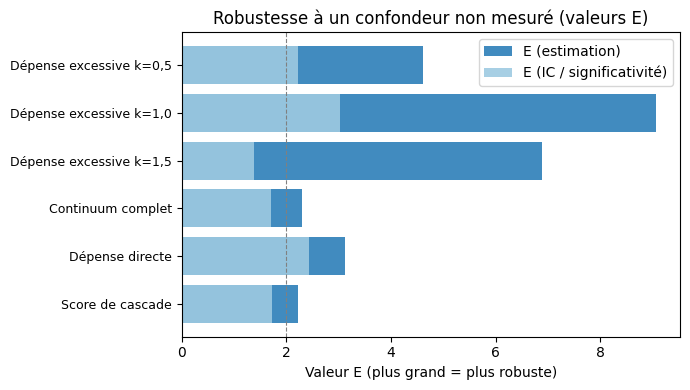

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
yy = np.arange(len(EV))
ax.barh(yy, EV['E_estimation'], color='#1f77b4', alpha=0.85, label='E (estimation)')
ax.barh(yy, EV['E_IC'], color='#9ecae1', alpha=0.9, label='E (IC / significativité)')
ax.axvline(2, color='grey', ls='--', lw=0.8)
ax.set_yticks(yy); ax.set_yticklabels(EV['résultat'], fontsize=9)
ax.set_xlabel('Valeur E (plus grand = plus robuste)')
ax.set_title('Robustesse à un confondeur non mesuré (valeurs E)')
ax.legend(); ax.invert_yaxis(); fig.tight_layout()
fig.savefig(f'{FIG_DIR}/valeurs_e.png', dpi=150)
plt.show()

In [5]:
EV.to_csv(f'{OUT_DIR}/sensibilite_evalues.csv', index=False, encoding='utf-8-sig')
ROS.to_csv(f'{OUT_DIR}/sensibilite_rosenbaum.csv', index=False, encoding='utf-8-sig')
print('Sauvegardé : sensibilite_evalues.csv, sensibilite_rosenbaum.csv, figure valeurs_e.png')

Sauvegardé : sensibilite_evalues.csv, sensibilite_rosenbaum.csv, figure valeurs_e.png
